## Set-up
* importing necessary packages and defining parameters

In [193]:
import numpy as np
import cv2
import math 
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors
from scipy.signal import argrelextrema
import pandas as pd
import csv
import os
from scipy.ndimage import gaussian_filter1d
import re

In [243]:
extension_factor = 1.1
step_size = 2
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2
mask_smoothing = True
window_size=21
smoothing_sigma=50
scale_factor=0.25

## *** IMPORTANT *** 
This code relies on the slice images and masks being in a folder called `testing_slices/`

Inside that folder, create a folder called `patch_outputs/` for the patches to be exported into

In [246]:
image_folder = './testing_slices_4'
image_files = [f for f in os.listdir(image_folder) if f.startswith('h&e')]

## Final patching code 

In [278]:
def gaussian_smooth_contour(contour, window_size=window_size, sigma=smoothing_sigma):
    """
    Smooths a contour by applying a Gaussian kernel to the x and y coordinates.
    
    Args:
        contour: A 2D array of contour points of shape (N, 2).
        window_size: The size of the Gaussian kernel (must be odd).
        sigma: Standard deviation of the Gaussian kernel.
        
    Returns:
        Smoothed contour as an integer array of shape (N, 2).
    """
    contour = contour.squeeze()  # shape (N, 2)
    N = len(contour)
    
    # Create a Gaussian kernel.
    x_range = np.arange(window_size) - window_size // 2
    kernel = np.exp(-(x_range**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    
    # Circularly pad the contour coordinates.
    padded_x = np.pad(contour[:, 0], (window_size // 2, window_size // 2), mode='wrap')
    padded_y = np.pad(contour[:, 1], (window_size // 2, window_size // 2), mode='wrap')
    
    # Convolve to smooth the x and y coordinates.
    smoothed_x = np.convolve(padded_x, kernel, mode='valid')
    smoothed_y = np.convolve(padded_y, kernel, mode='valid')
    
    smoothed_contour = np.stack([smoothed_x, smoothed_y], axis=-1)
    return np.round(smoothed_contour).astype(np.int32)

def compute_smoothed_mask(binary_mask, window_size=window_size, sigma=smoothing_sigma, scale_factor=scale_factor):
    """
    Compute a smoothed version of a binary mask by:
      1. Downscaling the mask.
      2. Extracting contours using RETR_TREE.
      3. Smoothing each contour with a Gaussian kernel.
      4. Upscaling the smoothed contours back to the original resolution.
      5. Drawing the contours into a new binary mask.
    
    Args:
      binary_mask (np.ndarray): Original binary mask (0/255).
      window_size (int): Window size for Gaussian smoothing.
      sigma (float): Sigma value for the Gaussian kernel.
      scale_factor (float): Downscaling factor.
    
    Returns:
      np.ndarray: A binary mask of the same dimensions as binary_mask, but with smoothed boundaries.
    """
    orig_h, orig_w = binary_mask.shape
    # Downscale the mask for processing.
    small_mask = cv2.resize(binary_mask, (0, 0), fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
    small_h, small_w = small_mask.shape

    # Extract contours from the downscaled mask.
    contours, hierarchy = cv2.findContours(small_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    # Prepare an empty mask for the final result.
    smoothed_mask = np.zeros_like(binary_mask)
    # Compute scaling factors to upscale the smoothed contours.
    scale_x = orig_w / small_w
    scale_y = orig_h / small_h

    for i, cnt in enumerate(contours):
        cnt = cnt.squeeze()  # Remove extra dimensions.
        if cnt.ndim != 2 or len(cnt) < 3:
            continue
        # Ensure the contour is closed.
        if not np.array_equal(cnt[0], cnt[-1]):
            cnt = np.vstack([cnt, cnt[0]])
        # Smooth the contour using your Gaussian smoothing function.
        smooth_cnt = gaussian_smooth_contour(cnt, window_size=window_size, sigma=sigma)
        # Upscale the smoothed contour to original resolution.
        smooth_cnt = (smooth_cnt.astype(np.float32) * np.array([scale_x, scale_y])).astype(np.int32)
        smooth_cnt = smooth_cnt.reshape((-1, 1, 2))
        # Use hierarchy info: if the contour has no parent, it’s an outer boundary.
        if hierarchy[0][i][3] == -1:
            cv2.drawContours(smoothed_mask, [smooth_cnt], -1, 255, -1)
        else:
            cv2.drawContours(smoothed_mask, [smooth_cnt], -1, 0, -1)
    
    return smoothed_mask

def get_contours(binary_image):
    '''Find all external contours of an image, handling hierarchy correctly for both single and nested structures.'''

    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # If no contours are found, return an empty list
    if hierarchy is None or len(contours) == 0:
        print("No contours found.")
        return []

    hierarchy = hierarchy[0]
    external_contours = []

    for i in range(len(contours)):
        if hierarchy[i][3] == -1:  # Check if contour has no parent (true external)
            external_contours.append(np.roll(contours[i], 0, axis=0))

    # If external contours seem incomplete (indicating nested structures exist), use the John's method
    if len(external_contours) < len(contours):  
        masks = []
        contour_indices = np.arange(0, hierarchy.shape[0], 1)

        while contour_indices.size != 0:
            current = contour_indices[0]
            contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == current))

            # Create a mask for the contour
            mask = np.zeros_like(binary_image)
            cv2.drawContours(mask, contours, current, 255, 1)

            # Draw child contours inside the mask
            for j in np.argwhere(hierarchy[:, 3] == current).ravel():
                contour_indices = np.delete(contour_indices, np.argwhere(contour_indices == j))
                cv2.drawContours(mask, contours, j, 255, 1)

            masks.append(mask)

        # Extract external contours from the masks
        for mask in masks:
            extracted_contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            external_contours.extend(extracted_contours)

    unique_contours = []
    for c in external_contours:
        if not any(np.array_equal(c, u) for u in unique_contours):
            unique_contours.append(c)

    return unique_contours


def better_normals(contours,binary_image):
    contours = [contour.reshape(-1, 2).astype(np.float32) for contour in contours]

    # Compute sigma values for Gaussian smoothing
    sigmas = np.array([max(len(contour) // 90, 1) for contour in contours])  # Avoid sigma=0

    # Apply Gaussian smoothing to X and Y coordinates
    smoothed_contours = [
        np.column_stack((gaussian_filter1d(contour[:, 0], sigma, mode='constant'),
                         gaussian_filter1d(contour[:, 1], sigma, mode='constant')))
        for contour, sigma in zip(contours, sigmas)
    ]

    # Compute gradients (tangents)
    gradients = [np.gradient(contour, axis=0) for contour in smoothed_contours]

    # Normalize tangents to get unit tangent vectors
    tangent_units = [tangent / (np.linalg.norm(tangent, axis=1, keepdims=True) + 1e-8) for tangent in gradients]

    # Rotate tangents to get normals
    normals = [np.column_stack((-tangent[:, 1], tangent[:, 0])) for tangent in tangent_units]

    return normals, tangent_units

def calculate_patch_corners(point, normal, binary_image, extension_factor=1.0, step_size=4, max_length=2048):
    """
    Calculate the corners of a square patch using epithelium width along the normal.

    Args:
        point (np.ndarray): The point on the contour.
        normal (np.ndarray): The normal vector at the point.
        binary_image (np.ndarray): Binary mask of the tissue.
        extension_factor (float): Factor to slightly enlarge the patch (e.g., 1.1 for 10% increase).
        step_size (int): Step size for checking tissue boundaries along the normal.
        max_length (int): Maximum distance to search for epithelium width.

    Returns:
        np.ndarray: The four corners of the square patch.
        int: The computed patch height.
    """
    height, width = binary_image.shape
    point = point.astype(int)

    # generating forward and backward points along the normal
    steps = np.arange(0, max_length, step_size)[:, None]
    points = np.clip(point - steps * normal, 0, [width - 1, height - 1]).astype(int)

    # extracting pixel values along the normal path
    values = binary_image[points[:, 1], points[:, 0]]

    # finding the first background pixel (where value == 0)
    stop = np.where(values == 0)[0]

    # computing distances
    width = stop[0] * step_size if stop.size > 0 else max_length

    # computing total epithelium width and adjust for stroma extension
    extended_length = int(width * extension_factor)
    
    half_size = extended_length // 2 

    # computing tangent vector (perpendicular to normal)
    tangent = np.array([-normal[1], normal[0]])

    # defining square corners (same logic as `calculate_square_corners`)
    corners = np.array([
        point + (tangent * half_size),
        point - (tangent * half_size),
        point - (tangent * half_size) - (normal * extended_length),
        point + (tangent * half_size) - (normal * extended_length)
    ])

    return corners, extended_length

# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for squares in patch_list:
        for square in squares:
            points=square.astype(np.int32)
            cv2.polylines(patches_on_slice,[points],isClosed=True,color=color,thickness=thickness)
    return patches_on_slice

def process_contours(slice_details,binary_image,overlap_thresh=0.3):
    """
    Main function to process multiple contours and generate aligned squares along them.
    
    Args:
        image (np.ndarray): Original image
        binary_image (np.ndarray): Binary mask of the shapes
        overlap_thresh (float): Maximum allowed overlap between squares        
    Returns:
        tuple: (processed image, contours, squares_list)
    """
    contours=get_contours(binary_image)
    
    if not contours:
        return TypeError('No contours found')
    
    #Condition check for square creation
    #normals=calculate_contour_normals(contours,smoothing_size)
    normals, tangents=better_normals(contours,binary_image)
    final_squares_list, patch_length_list = create_smarter_squares(contours,normals,binary_image,overlap_thresh=overlap_thresh)
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)

    result = draw_patches(tissue_slice,final_squares_list)
    
    return result, contours, final_squares_list, normals, tangents


# Function to calculate patch overlap
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

def create_smarter_squares(contours,normals,binary_image,overlap_thresh):
    '''Create squares that meet overlap thresh with last square'''
    return_squares=[]
    all_patch_lengths = []
    
    #Loop over all contours and get corresponding normals to point
    for contour, contour_normals in zip(contours,normals):
        points=contour.reshape(-1,2)
        squares=[]
        contour_patch_lengths = []
        last_square=None

        #Go over points, evaluating if next square's corner falls outside of range of last square
        for i,point in enumerate(points):

            corners,length=calculate_patch_corners(point,contour_normals[i],binary_image)

            #Prevent poorly sized squares
            #Finding rough area approximation in terms of patch length
            side_length = np.sqrt(cv2.contourArea(contour))
            #Approximately: Want squares less than 50% of contour area, and minimum of 2% area
            if length>side_length*.50 or length<side_length*0.02:
                continue
            #Check to see if first square and check agaisnt last square to prevent long loop
            elif last_square is not None and patch_overlap(last_square,corners)>overlap_thresh:
                continue
            #Check agasint all squares, prevents issues of larger patches covering thin sections of epithelium next to large ones 
            elif any(patch_overlap(corners, square)>overlap_thresh for square in squares)==True:
                continue
        
            squares.append(corners)
            last_square=corners
            contour_patch_lengths.append(length)

        return_squares.append(squares)
        all_patch_lengths.append(contour_patch_lengths)
    return return_squares, all_patch_lengths

In [280]:
def empty_folder():
    # delete everything out of directory
    output_folder = 'testing_slices_4/patch_outputs'
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist
    for file in os.listdir(output_folder):
        file_path = os.path.join(output_folder, file)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            os.rmdir(file_path)

# Export patched slice into a new folder 
def export_patched_slice(patched_slice_name, selected_patches_on_slice):

    output_folder = os.path.join('testing_slices_4', 'patch_images')
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist

    output_path = os.path.join(output_folder, os.path.basename(patched_slice_name))
    cv2.imwrite(output_path, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

# Calculate performance metrics
def calculate_metrics(epithelium_mask_2D, all_selected_patches):

    num_patches = len(np.vstack(all_selected_patches))

    total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
    patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

    #For all patches in all contours, use them to create a mask
    for contour_patches in all_selected_patches:
        for patch in contour_patches:
            patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(patch_mask, [patch], 255)

    number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

    covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
    covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

    total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
    background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
    score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

    # Exporting performance metrics and parameter values
    metrics = pd.DataFrame({'Metric':['num_patches','total_epithelium_coverage', 'background_pixel_percent',
                        'score', 'extension_factor', 'step_size',
                        'max_width', 'overlap_threshold'], 
                'Value':[num_patches, total_epithelium_coverage, background_pixel_percent, score, 
                        extension_factor, step_size, max_width, overlap_threshold]})

    return metrics

def find_edges(all_selected_patches):
    all_points = np.vstack(all_selected_patches[0])

    edges = {'min_x': np.min(all_points[:, 0]),
             'max_x': np.max(all_points[:, 0]),
             'min_y': np.min(all_points[:, 1]),
             'max_y': np.max(all_points[:, 1])}

    return edges

def add_padding(image, edges):
        
    height, width, channels = image.shape

    if edges['min_x'] < 0:
        left = math.ceil(np.abs(edges['min_x']))
    else: left = 0

    if edges['max_x'] > width:
        right = math.ceil(edges['max_x'] - width)
    else: right = 0

    if edges['min_y'] < 0:
        top = math.ceil(np.abs(edges['min_y']))
    else: top = 0

    if edges['max_y'] > height:
        bottom = math.ceil(edges['max_y'] - height)
    else: bottom = 0

    new_width = width + right + left
    new_height = height + top + bottom
    

    # compute the padding color using the mode pixel value
    threshold = 150
    mask = np.all(image>threshold, axis = -1)
    if np.any(mask):
        bright_pixels = image[mask]
        if np.issubdtype(image.dtype,np.integer):
            dims = (np.iinfo(image.dtype).max + 1,) * channels
            combined = np.ravel_multi_index(bright_pixels.T,dims)
            unique_vals, counts = np.unique(combined, return_counts = True)
            mode_val = unique_vals[np.argmax(counts)]
            mode_color = np.array(np.unravel_index(mode_val, dims)).astype(image.dtype)
            pad_color = mode_color.flatten()
        else:
            pixels, counts = np.unique(bright_pixels, axis = 0, return_counts = True)
            pad_color = pixels[np.argmax(counts)]
    else:
        pad_color = np.array([threshold] * channels , dtype = image.dtype)


    padded_image = np.ones((new_height, new_width, channels), dtype=image.dtype) * pad_color

    # Insert the original image into the array of updated dimensions
    padded_image[top:top + height, left:left + width] = image


    return padded_image, right, left, top, bottom

# Shift patches by padding amount
def shift_patches(padded_image, all_selected_patches, left, top):

    all_points = np.vstack(all_selected_patches)

    shift_x = left
    shift_y = top
    shift_array = np.array([shift_x, shift_y])
    shifted_points = all_points + shift_array
    shifted_points = np.vstack(shifted_points)
    shifted_points = np.split(shifted_points, len(shifted_points) // 4)
    shifted_points = [shifted_points]   

    shifted_patches_on_slice = draw_patches(padded_image, shifted_points)

    return shifted_patches_on_slice, shifted_points

# edited to 
def show_shifted_patches(image, padded_image, all_selected_patches, shifted_patches_on_slice, binary_image):
    # Convert grayscale mask to RGB for overlaying patches
    mask_rgb = cv2.cvtColor(binary_image, cv2.COLOR_GRAY2RGB)

    # Plot the original image and the patched mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    result = draw_patches(image,all_selected_patches)
    mask = draw_patches(mask_rgb,all_selected_patches)
    #mask = mask_rgb
    axes[0].imshow(result)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(mask)
    axes[1].set_title("Grayscale Mask with Patches")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    result = cv2.hconcat([result,mask])
    return result


def extract_square_images(image, points):
    
    patch_images = []
    square_list = np.vstack(points)

    for square in square_list:

        # create an empty mask with white inside just the square's region
        square = square.astype(np.int32)
        square.reshape((-1,1,2)) # bc cv2.fillpoly expects points to be in shape (N,1,2)
        mask = np.zeros(image.shape[:2],dtype = np.uint8)
        cv2.fillPoly(mask, [square], 255)

        # Apply the mask to the image
        masked_image = cv2.bitwise_and(image, image, mask = mask)

        # uncomment to see placement of patch within the entire slice image 
        # plt.imshow(masked_image)
        # plt.show()

        # Crop the image around the rotated square (will have black space due to rotation)
        x_min = np.min(square[:, 0])
        x_max = np.max(square[:, 0])
        y_min = np.min(square[:, 1])
        y_max = np.max(square[:, 1])
        cropped_image = masked_image[y_min:y_max, x_min:x_max]

        # rotate the cropped image to be parallel to the xy axis
        # calculate the angle the patch needs to be rotated by
        point1 = square[0]  # top-left corner
        point2 = square[1]  # top-right corner
        vector = point2 - point1
        angle_degrees = np.arctan2(vector[1], vector[0]) * (180.0 / np.pi) - 180

        # Get the center of the cropped image
        center = (int((x_max - x_min)) // 2, int((y_max - y_min)) // 2)

        # Create the rotation matrix to rotate around the center
        rotation_matrix = cv2.getRotationMatrix2D(center, angle_degrees, 1.0) # 1.0 means image wont be scaled

        # Rotate the cropped image to make it parallel to xy axis
        if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
            rotated_patch = cv2.warpAffine(cropped_image, 
                                        rotation_matrix,
                                        (cropped_image.shape[1], cropped_image.shape[0]))  # output image size
        else:
            print("Cropped image is empty, skipping rotation.")

        # remove the extra black pixels around the edges
        gray = cv2.cvtColor(rotated_patch, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        x, y, w, h = cv2.boundingRect(contours[0])
        cropped_img = rotated_patch[y:y+h, x:x+w]

        patch_images.append(cropped_img)
    
    return patch_images

def save_patches(patch_images, slice_name):
    # Ensure output directory exists
    output_folder = os.path.join("testing_slices_4","patch_outputs")
    if not os.path.exists(output_folder):  # Check if folder exists
        os.makedirs(output_folder)  # Create folder if it doesn't exist
    # Clean file name
    file_name = os.path.basename(slice_name).replace('mask', '').replace('.png', '')
    
    # Save patches
    for i, patch in enumerate(patch_images):
        output_path = os.path.join(output_folder, f"{file_name}_patch{i}.png")
        cv2.imwrite(output_path, patch)

def patching_export(binary, slice_name, slice_details):
    " processes tissue slice to create and export patches"
    
    # Process contours and generate patch squares
    result, contours, final_squares, normals, tangents = process_contours(slice_details, binary, 0.2)    
    
    # calculate metrics
    metrics = calculate_metrics(binary, final_squares)
    
    # find edges and add padding
    edges = find_edges(final_squares)
    tissue_slice = cv2.cvtColor(cv2.imread(slice_details), cv2.COLOR_BGR2RGB)
    padded_image, right, left, top, bottom = add_padding(tissue_slice, edges)
    _, shifted_points = shift_patches(padded_image, final_squares, left, top)
    result = show_shifted_patches(tissue_slice, padded_image, final_squares, shifted_points, binary)

    # export patched slice
    patched_slice_name = slice_details.replace('testing_slices_4/', 'patched_')
    export_patched_slice(patched_slice_name.replace('.tif', '.png'), result)

    # extract square patch images
    patched_images = extract_square_images(padded_image, shifted_points)

    # save patches to output folder
    save_patches(patched_images, slice_name)

    return metrics, patched_images, result, contours, final_squares, normals, tangents

## Patch export pipeline
The following pipeline requires you have a folder called 'testing_slices' which contains masks (pngs) and original slice images (tifs)

Each image (pngs and tifs) must all follow the format: `case_{case_number}_match_{match_number}_{h&e/melan/sox10}`

The code below turns all the mask/slice matches in your folder into a list of tuples for the patching_export algorithm to run over

('testing_slices_4/case_67_match_1_h&e.png', 'testing_slices_4/case_67_match_1_h&e.tif')


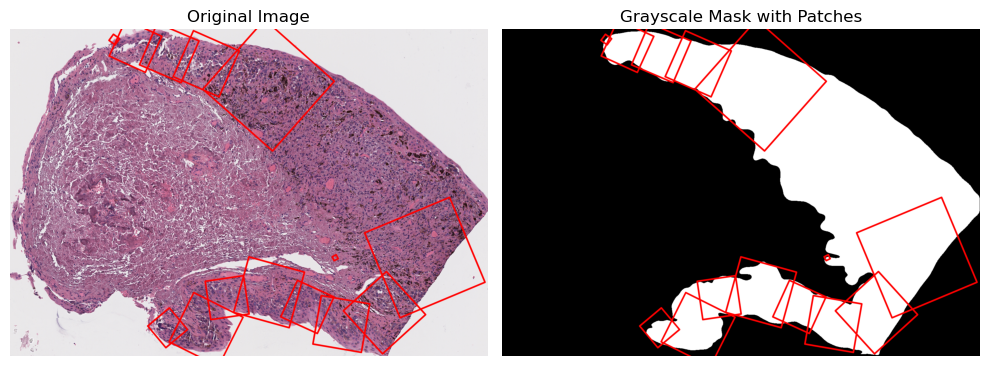

Saved final_squares and result.
                      Metric        Value
0                num_patches    14.000000
1  total_epithelium_coverage    57.892744
2   background_pixel_percent    17.191798
3                      score    62.875835
4           extension_factor     1.100000
5                  step_size     2.000000
6                  max_width  2048.000000
7          overlap_threshold     0.300000
[[[235 234 239]
  [235 233 236]
  [234 232 235]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[235 235 237]
  [237 235 238]
  [235 233 236]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[233 233 235]
  [234 232 235]
  [232 230 231]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 ...

 [[231 229 232]
  [233 231 234]
  [227 225 228]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[233 231 234]
  [232 230 233]
  [225 223 226]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[233 231 234]
  [230 228 231]
  [227 225 228]
  ...
  [  0   0

In [283]:
# Path to your folder
image_folder = "testing_slices_4" # put folder path here

# Dictionary to store matches
cases = {}

# Iterate over files in the folder
for filename in os.listdir(image_folder):
    match = re.match(r"case_(\d+)_match_(\d+)_(h&e|melan|sox10).*\.(png|tif)", filename)
    if match:
        case_number, match_number, scan_type, extension = match.groups()
        case_number, match_number = int(case_number), int(match_number)  # Convert to int for sorting
        
        if case_number not in cases:
            cases[case_number] = {}

        if match_number not in cases[case_number]:
            cases[case_number][match_number] = {}

        if scan_type not in cases[case_number][match_number]:
            cases[case_number][match_number][scan_type] = {"mask": "None", "slice": "None"}

        if extension == "png":
            cases[case_number][match_number][scan_type]["mask"] = os.path.join(image_folder, filename)
            
        elif extension == "tif":
            cases[case_number][match_number][scan_type]["slice"] = os.path.join(image_folder, filename)

# Build list of tuples (mask, slice), ensuring both exist
matched_pairs = []
masks = []
for case in cases.values():
    for match in case.values():
        for scan in match.values():
            if 'mask' in scan:
                matched_pairs.append((scan['mask'], scan['slice']))


# delete any patches that are already in the directory
empty_folder()

# Run patching and exporting over list of tuples
for i, m in enumerate(matched_pairs, 1):
    print(m)
    image1 = cv2.imread(m[0])
    image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    _,whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)
    if mask_smoothing == True:
        # Compute the smoothed mask.
        smoothed_binary = compute_smoothed_mask(whole_thresh1)
        # Use the smoothed mask in your patching/export pipeline.
        metrics, images, result, contours, final_squares, normals, tangents = patching_export(smoothed_binary, m[0], m[1])
    else:
        metrics, images, result, contours, final_squares, normals, tangents = patching_export(whole_thresh1, m[0], m[1])  # (binary, slice_name, slice_details) aka (binary image, epithelium annotation png, tif)
    import pickle

# Assuming there's only one file, take the first processed result
    if matched_pairs:
        with open("final_squares.pkl", "wb") as f:
            pickle.dump(final_squares, f)

        with open("result.pkl", "wb") as f:
            pickle.dump(result, f)
            
        with open("normals.pkl", "wb") as f:
            pickle.dump(normals, f)
            
        with open("tangents.pkl", "wb") as f:
            pickle.dump(tangents, f)

    print("Saved final_squares and result.")
    print(metrics)
    print(result)
    print(contours)
    print(final_squares)
    print(normals)
    print(tangents)
    

In [255]:
import pickle

with open("final_squares.pkl", "rb") as f:
    final_squares = pickle.load(f)

with open("result.pkl", "rb") as f:
    result = pickle.load(f)
    
with open("normals.pkl", "rb") as f:
    normals = pickle.load(f)
    
with open("tangents.pkl", "rb") as f:
    tangents = pickle.load(f)

In [256]:
def draw_patches(image, patch_list, color=[255, 0, 0], thickness=20, patch_index=None):
    """
    Draw patches on the image. If patch_index is provided, draw only that patch.
    
    Args:
        image (np.ndarray): The original image.
        patch_list (list): List of patches (each patch is a list of points).
        color (list): Color of the patches (BGR format).
        thickness (int): Thickness of the patch boundary.
        patch_index (tuple or None): Index of the patch to draw (e.g., (i, j)). If None, draw all patches.
    
    Returns:
        np.ndarray: Image with patches drawn.
    """
    patches_on_slice = image.copy()
    
    if patch_index is not None:
        # Draw only the specified patch
        i, j = patch_index
        square = patch_list[i][j]
        points = square.astype(np.int32)
        cv2.polylines(patches_on_slice, [points], isClosed=True, color=color, thickness=thickness)
    else:
        # Draw all patches
        for squares in patch_list:
            for square in squares:
                points = square.astype(np.int32)
                cv2.polylines(patches_on_slice, [points], isClosed=True, color=color, thickness=thickness)
    
    return patches_on_slice

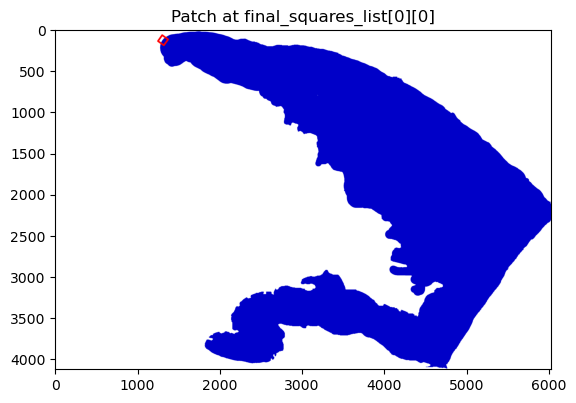

In [257]:
# Example: Visualize the patch at final_squares_list[i][j]
i, j = 0, 0  # Replace with the indices of the patch you want to visualize
result_with_one_patch = draw_patches(image1, final_squares, patch_index=(i, j))

# Display the result
plt.imshow(result_with_one_patch)
plt.title(f"Patch at final_squares_list[{i}][{j}]")
plt.show()

In [258]:
print(final_squares[0][0])
print(normals[0][0])
print(tangents[0][0])

[[1251.26971817  146.32224846]
 [1322.73028183  197.67775154]
 [1374.08578491  126.21718788]
 [1302.62522125   74.8616848 ]]
[-0.12758173  0.9918281 ]
[0.9918281  0.12758173]


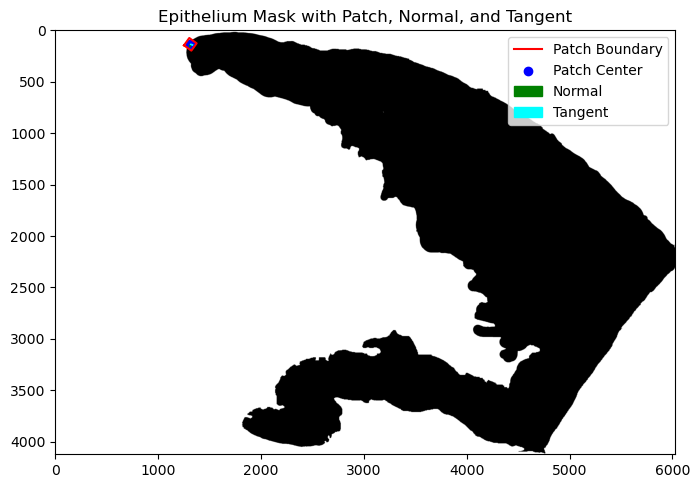

In [259]:
# Load the epithelium mask (1.png)
epithelium_mask = cv2.imread("testing_slices_4/case_67_match_1_h&e.png", cv2.IMREAD_GRAYSCALE)

# Get the four corners of the patch
patch_corners = final_squares[0][0]  # Shape: (4, 2)

# Get the center of the patch
patch_center = np.mean(patch_corners, axis=0)

# Get the normal and tangent vectors at this patch
normal = normals[0][13]
tangent = tangents[0][13]

# Scale vectors for visualization
scale = 20
normal_vector = patch_center + scale * normal
tangent_vector = patch_center + scale * tangent

# Plot the epithelium mask
plt.figure(figsize=(8, 8))
plt.imshow(epithelium_mask, cmap='gray')

# Plot the patch corners
patch_corners = np.vstack([patch_corners, patch_corners[0]])  # Close the patch shape
plt.plot(patch_corners[:, 0], patch_corners[:, 1], 'r-', label="Patch Boundary")

# Plot the patch center
plt.scatter(*patch_center, color='blue', label="Patch Center")

# Plot the normal and tangent vectors
plt.arrow(patch_center[0], patch_center[1], normal_vector[0] - patch_center[0], normal_vector[1] - patch_center[1],
          color='green', head_width=5, label="Normal")
plt.arrow(patch_center[0], patch_center[1], tangent_vector[0] - patch_center[0], tangent_vector[1] - patch_center[1],
          color='cyan', head_width=5, label="Tangent")

# Display the plot
plt.legend()
plt.title("Epithelium Mask with Patch, Normal, and Tangent")
plt.show()


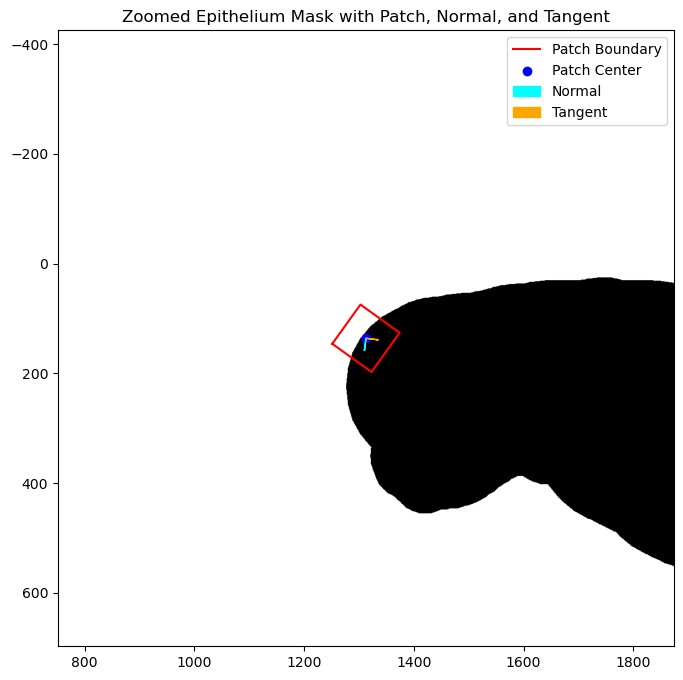

In [260]:
# Load the epithelium mask (1.png)
epithelium_mask = cv2.imread("testing_slices_4/case_67_match_1_h&e.png", cv2.IMREAD_GRAYSCALE)

# Get the four corners of the patch
patch_corners = final_squares[0][0]  # Shape: (4, 2)

# Get the center of the patch
patch_center = np.mean(patch_corners, axis=0)

# Get the normal and tangent vectors at this patch
normal = normals[0][0]
tangent = tangents[0][0]

# Scale vectors for visualization
scale = 20
normal_vector = patch_center + scale * normal
tangent_vector = patch_center + scale * tangent

# Set zoom area (expand around patch)
zoom_margin = 500
x_min, x_max = np.min(patch_corners[:, 0]) - zoom_margin, np.max(patch_corners[:, 0]) + zoom_margin
y_min, y_max = np.min(patch_corners[:, 1]) - zoom_margin, np.max(patch_corners[:, 1]) + zoom_margin

# Plot the epithelium mask with zoom
plt.figure(figsize=(8, 8))
plt.imshow(epithelium_mask, cmap='gray')

# Plot the patch corners
patch_corners = np.vstack([patch_corners, patch_corners[0]])  # Close the patch shape
plt.plot(patch_corners[:, 0], patch_corners[:, 1], 'r-', label="Patch Boundary")

# Plot the patch center
plt.scatter(*patch_center, color='blue', label="Patch Center")

# Plot the normal and tangent vectors
plt.arrow(patch_center[0], patch_center[1], normal_vector[0] - patch_center[0], normal_vector[1] - patch_center[1],
          color='cyan', head_width=2, label="Normal")
plt.arrow(patch_center[0], patch_center[1], tangent_vector[0] - patch_center[0], tangent_vector[1] - patch_center[1],
          color='orange', head_width=2, label="Tangent")

# Adjust plot limits for zoom
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().invert_yaxis()  # Ensure y-axis is correctly oriented

# Display the plot
plt.legend()
plt.title("Zoomed Epithelium Mask with Patch, Normal, and Tangent")
plt.show()


In [261]:
image1 = cv2.imread('testing_slices_4/case_67_match_1_h&e.png')
image1_gray = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
_,whole_thresh1=cv2.threshold(image1_gray,240,255,cv2.THRESH_BINARY_INV)
smoothed_binary = compute_smoothed_mask(whole_thresh1)

In [262]:
contours = get_contours(smoothed_binary)

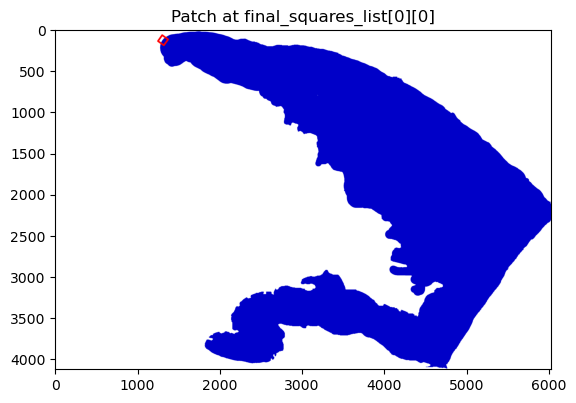

In [263]:
# Example: Visualize the patch at final_squares_list[i][j]
i, j = 0, 0  # Replace with the indices of the patch you want to visualize
result_with_one_patch = draw_patches(image1, final_squares, patch_index=(i, j))

# Display the result
plt.imshow(result_with_one_patch)
plt.title(f"Patch at final_squares_list[{i}][{j}]")
plt.show()

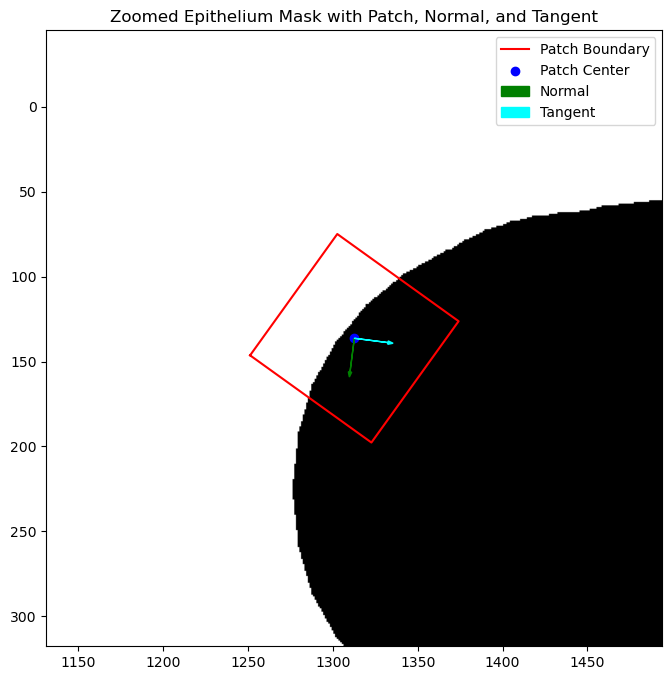

In [264]:
# Load the epithelium mask (1.png)
epithelium_mask = cv2.imread("testing_slices_4/case_67_match_1_h&e.png", cv2.IMREAD_GRAYSCALE)

# Get the four corners of the patch
patch_corners = final_squares[0][0]  # Shape: (4, 2)

# Get the center of the patch
patch_center = np.mean(patch_corners, axis=0)
5
# Get the normal and tangent vectors at this patch
normal = normals[0][0]
tangent = tangents[0][0]

# Scale vectors for visualization
scale = 20
normal_vector = patch_center + scale * normal
tangent_vector = patch_center + scale * tangent

# Set zoom area (expand around patch)
zoom_margin = 120
x_min, x_max = np.min(patch_corners[:, 0]) - zoom_margin, np.max(patch_corners[:, 0]) + zoom_margin
y_min, y_max = np.min(patch_corners[:, 1]) - zoom_margin, np.max(patch_corners[:, 1]) + zoom_margin

# Plot the epithelium mask with zoom
plt.figure(figsize=(8, 8))
plt.imshow(epithelium_mask, cmap='gray')

# Plot the patch corners
patch_corners = np.vstack([patch_corners, patch_corners[0]])  # Close the patch shape
plt.plot(patch_corners[:, 0], patch_corners[:, 1], 'r-', label="Patch Boundary")

# Plot the patch center
plt.scatter(*patch_center, color='blue', label="Patch Center")

# Plot the normal and tangent vectors
plt.arrow(patch_center[0], patch_center[1], normal_vector[0] - patch_center[0], normal_vector[1] - patch_center[1],
          color='green', head_width=2, label="Normal")
plt.arrow(patch_center[0], patch_center[1], tangent_vector[0] - patch_center[0], tangent_vector[1] - patch_center[1],
          color='cyan', head_width=2, label="Tangent")

# Adjust plot limits for zoom
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().invert_yaxis()  # Ensure y-axis is correctly oriented

# Display the plot
plt.legend()
plt.title("Zoomed Epithelium Mask with Patch, Normal, and Tangent")
plt.show()
